# Notebook 03: Chunking Strategies

**Time:** ~30 minutes  
**Goal:** Compare four chunking strategies (fixed, recursive, sentence-aware, semantic, contextual) and feel why chunk size dominates RAG quality.

This notebook will:
1. Implement **recursive** character chunking (LangChain's default) without LangChain
2. Compare it with **sentence-aware** chunking
3. Use embeddings to do **semantic chunking** (split where meaning shifts)
4. Apply **contextual retrieval** (Anthropic 2024) — prepend an LLM-generated context blurb
5. Visualize chunk-length distributions and reflect on retrieval implications

> **Why chunk size matters:** smaller chunks (~256 tokens) maximize *precision* (tight matches). Larger chunks (~1024) maximize *context*. The sweet spot is corpus-dependent — your homework is to find yours.


## Setup


In [12]:
import os, sys, time, importlib, json
from pathlib import Path

notebook_dir = os.getcwd()
parent_dir   = str(Path(notebook_dir).parent)
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

from dotenv import load_dotenv
load_dotenv(os.path.join(parent_dir, '.env'), override=True)

import src.llm_client, src.cost_tracker, src.utils, src.config
import src.document_loader, src.chunking
for mod in [src.llm_client, src.cost_tracker, src.utils, src.config,
            src.document_loader, src.chunking]:
    importlib.reload(mod)

from src.llm_client import LLMClient
from src.cost_tracker import CostTracker
from src.utils import format_response, append_to_reflection
from src.document_loader import load_pdf, load_directory
from src.chunking import (
    recursive_chunk, sentence_chunk, semantic_chunk, contextual_chunk,
    attach_metadata,
)
import src.config as config

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

client  = LLMClient(path=config.PATH)
tracker = CostTracker()

outputs_dir = os.path.join('..', 'outputs')
test_data   = os.path.join('..', 'test_data')

print('Setup complete -- ready for Notebook 03')


✓ Claude API client initialized
  Default model: claude-sonnet-4-6
  Available: claude-sonnet-4-6, claude-opus-4-6, claude-haiku-4-5-20251001
Setup complete -- ready for Notebook 03


## Load a long document to chunk


In [13]:
# Use whichever you have: an arXiv paper > resume
arxiv_dir = os.path.join(test_data, 'arxiv')
candidate = None
if os.path.isdir(arxiv_dir):
    pdfs = sorted(f for f in os.listdir(arxiv_dir) if f.endswith('.pdf'))
    if pdfs:
        candidate = os.path.join(arxiv_dir, pdfs[0])
if not candidate:
    candidate = os.path.join(test_data, 'sample_resume.pdf')

doc = load_pdf(candidate)
text = doc['text']
print(f'Source: {os.path.basename(candidate)}, {len(text):,} chars')


  ✓ Loaded 2604.15224v1.pdf: 18 pages, 45,757 chars (via pymupdf)
Source: 2604.15224v1.pdf, 45,757 chars


## Part 1 — Recursive character chunking

The workhorse of LangChain and most production RAG. Walks a hierarchy of separators (paragraph → line → sentence → word → char) and splits at the highest level that fits.


In [14]:
print('=' * 65)
print('Experiment 1: recursive_chunk @ size=500, overlap=50')
print('=' * 65)

chunks_500 = recursive_chunk(text, chunk_size=500, overlap=50)
print(f'Got {len(chunks_500)} chunks. Lengths: '
      f'min={min(len(c) for c in chunks_500)}, '
      f'max={max(len(c) for c in chunks_500)}, '
      f'mean={int(np.mean([len(c) for c in chunks_500]))}')
print()
print('--- First chunk ---')
print(chunks_500[0])
print()
print('--- Second chunk (note overlap) ---')
print(chunks_500[1] if len(chunks_500) > 1 else '(only one chunk)')


Experiment 1: recursive_chunk @ size=500, overlap=50
  ✓ recursive_chunk: 8 chunks (size~500, overlap=50)
  ✓ recursive_chunk: 9 chunks (size~500, overlap=50)
  ✓ recursive_chunk: 10 chunks (size~500, overlap=50)
  ✓ recursive_chunk: 8 chunks (size~500, overlap=50)
  ✓ recursive_chunk: 7 chunks (size~500, overlap=50)
  ✓ recursive_chunk: 6 chunks (size~500, overlap=50)
  ✓ recursive_chunk: 8 chunks (size~500, overlap=50)
  ✓ recursive_chunk: 6 chunks (size~500, overlap=50)
  ✓ recursive_chunk: 7 chunks (size~500, overlap=50)
  ✓ recursive_chunk: 7 chunks (size~500, overlap=50)
  ✓ recursive_chunk: 4 chunks (size~500, overlap=50)
  ✓ recursive_chunk: 8 chunks (size~500, overlap=50)
  ✓ recursive_chunk: 2 chunks (size~500, overlap=50)
  ✓ recursive_chunk: 3 chunks (size~500, overlap=50)
  ✓ recursive_chunk: 2 chunks (size~500, overlap=50)
  ✓ recursive_chunk: 3 chunks (size~500, overlap=50)
  ✓ recursive_chunk: 5 chunks (size~500, overlap=50)
  ✓ recursive_chunk: 3 chunks (size~500, over

Now sweep three chunk sizes to see the trade-off:


  ✓ recursive_chunk: 22 chunks (size~200, overlap=20)
  ✓ recursive_chunk: 22 chunks (size~200, overlap=20)
  ✓ recursive_chunk: 25 chunks (size~200, overlap=20)
  ✓ recursive_chunk: 20 chunks (size~200, overlap=20)
  ✓ recursive_chunk: 19 chunks (size~200, overlap=20)
  ✓ recursive_chunk: 14 chunks (size~200, overlap=20)
  ✓ recursive_chunk: 21 chunks (size~200, overlap=20)
  ✓ recursive_chunk: 16 chunks (size~200, overlap=20)
  ✓ recursive_chunk: 19 chunks (size~200, overlap=20)
  ✓ recursive_chunk: 18 chunks (size~200, overlap=20)
  ✓ recursive_chunk: 10 chunks (size~200, overlap=20)
  ✓ recursive_chunk: 20 chunks (size~200, overlap=20)
  ✓ recursive_chunk: 3 chunks (size~200, overlap=20)
  ✓ recursive_chunk: 8 chunks (size~200, overlap=20)
  ✓ recursive_chunk: 5 chunks (size~200, overlap=20)
  ✓ recursive_chunk: 6 chunks (size~200, overlap=20)
  ✓ recursive_chunk: 12 chunks (size~200, overlap=20)
  ✓ recursive_chunk: 8 chunks (size~200, overlap=20)
  ✓ recursive_chunk: 268 chunks (

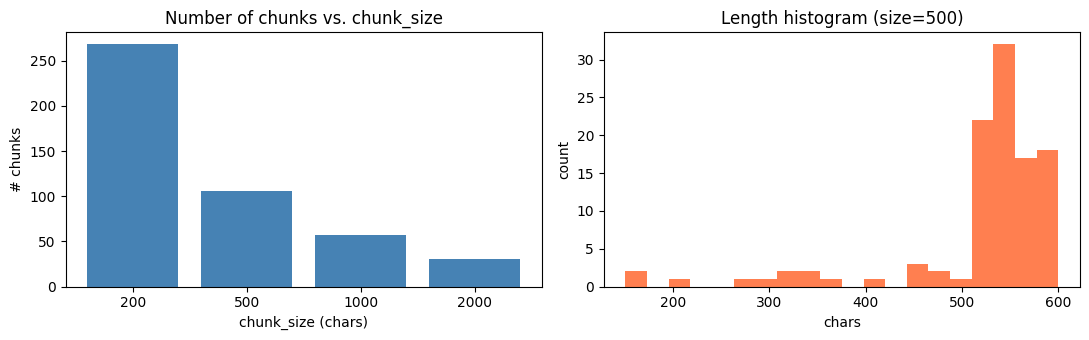

In [15]:
sizes = [200, 500, 1000, 2000]
stats = []
for s in sizes:
    cs = recursive_chunk(text, chunk_size=s, overlap=int(s*0.1))
    stats.append({'size': s, 'n_chunks': len(cs),
                  'mean_len': int(np.mean([len(c) for c in cs]))})
for st in stats:
    print(f'  size={st["size"]:5d}  n_chunks={st["n_chunks"]:4d}  mean_len={st["mean_len"]}')

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].bar([str(st['size']) for st in stats], [st['n_chunks'] for st in stats], color='steelblue')
ax[0].set_title('Number of chunks vs. chunk_size')
ax[0].set_xlabel('chunk_size (chars)'); ax[0].set_ylabel('# chunks')
lens_500 = [len(c) for c in chunks_500]
ax[1].hist(lens_500, bins=20, color='coral')
ax[1].set_title('Length histogram (size=500)')
ax[1].set_xlabel('chars'); ax[1].set_ylabel('count')
plt.tight_layout(); plt.show()


## Part 2 — Sentence-aware chunking

Recursive splits sometimes break mid-sentence. Sentence-aware never does — at the cost of less uniform sizes.


In [16]:
print('=' * 65)
print('Experiment 2: sentence_chunk @ max_tokens=128, overlap=1 sentence')
print('=' * 65)

sent_chunks = sentence_chunk(text, max_tokens=128, overlap_sentences=1)
print(f'Got {len(sent_chunks)} chunks.')
print()
print('--- First sentence-chunk ---')
print(sent_chunks[0])


Experiment 2: sentence_chunk @ max_tokens=128, overlap=1 sentence
  ✓ sentence_chunk: 97 chunks (max_tokens=128, overlap_sentences=1)
Got 97 chunks.

--- First sentence-chunk ---
Preprint. Under review. Context Over Content: Exposing Evaluation Faking in Auto-
mated Judges
Manan Gupta1
Inderjeet Nair2
Lu Wang2
Dhruv Kumar1
1BITS Pilani, India
2University of Michigan
{f20241231, dhruv.kumar}@pilani.bits-pilani.ac.in
{inair, wangluxy}@umich.edu
Abstract
The LLM-as-a-judge paradigm has become the operational backbone of au-
tomated AI evaluation pipelines, yet rests on an unverified assumption:
that judges evaluate text strictly on its semantic content, impervious to
surrounding contextual framing.


## Part 3 — Semantic chunking

Splits where the *meaning* shifts. Embeds each sentence, computes consecutive cosine distances, breaks on outliers.

We'll use `sentence-transformers/all-MiniLM-L6-v2` (384d, very fast).


In [17]:
print('=' * 65)
print('Experiment 3: semantic_chunk via all-MiniLM-L6-v2')
print('=' * 65)

from sentence_transformers import SentenceTransformer
embed_model = SentenceTransformer('all-MiniLM-L6-v2')
embed_fn = lambda texts: embed_model.encode(texts, show_progress_bar=False)

sem_chunks = semantic_chunk(text, embed_fn=embed_fn, threshold_percentile=90.0, min_sentences=2)
print(f'Got {len(sem_chunks)} chunks.')
print()
print('--- First semantic chunk ---')
print(sem_chunks[0][:400])


Experiment 3: semantic_chunk via all-MiniLM-L6-v2


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  ✓ semantic_chunk: 35 chunks (threshold p90=0.922, breakpoints=42)
Got 35 chunks.

--- First semantic chunk ---
Preprint. Under review. Context Over Content: Exposing Evaluation Faking in Auto-
mated Judges
Manan Gupta1
Inderjeet Nair2
Lu Wang2
Dhruv Kumar1
1BITS Pilani, India
2University of Michigan
{f20241231, dhruv.kumar}@pilani.bits-pilani.ac.in
{inair, wangluxy}@umich.edu
Abstract
The LLM-as-a-judge paradigm has become the operational backbone of au-
tomated AI evaluation pipelines, yet rests on an unv


## Part 4 — Contextual retrieval (Anthropic 2024)

Idea: before embedding each chunk, ask an LLM to write 1-2 sentences positioning it within the whole doc. Prepend that to the chunk. Empirically reduces retrieval failure by **35-49%**.

We use Claude Haiku 4.5 + restrict to 6 chunks for cost ($).


In [18]:
print('=' * 65)
print('Experiment 4: contextual_chunk on first 6 recursive chunks')
print('=' * 65)

ctx_chunks = contextual_chunk(
    chunks=chunks_500[:6],
    full_document=text,
    llm_client=client,
    max_chunks=6,
)
for r in ctx_chunks[:6]:
    tracker_calls_before = len(tracker.calls)
    # contextual_chunk doesn't currently call tracker.add_call; track approx

print()
print('--- Contextualized chunk 0 ---')
print(ctx_chunks[0])
print()
print('--- Original chunk 0 (for comparison) ---')
print(chunks_500[0])


Experiment 4: contextual_chunk on first 6 recursive chunks
  Contextualizing 6 chunks via LLM...
    [5/6] done
  ✓ contextual_chunk: contextualized 6 chunks

--- Contextualized chunk 0 ---
Context: This chunk is the title page and opening of a research paper that investigates whether LLM-based evaluators are biased by contextual framing about the consequences of their verdicts, rather than evaluating content objectively.

Preprint. Under review.
Context Over Content: Exposing Evaluation Faking in Auto-
mated Judges
Manan Gupta1
Inderjeet Nair2
Lu Wang2
Dhruv Kumar1
1BITS Pilani, India
2University of Michigan
{f20241231, dhruv.kumar}@pilani.bits-pilani.ac.in
{inair, wangluxy}@umich.edu
Abstract
The LLM-as-a-judge paradigm has become the operational backbone of au-
tomated AI evaluation pipelines, yet rests on an unverified assumption:
that judges evaluate text strictly on its semantic content, impervious to

--- Original chunk 0 (for comparison) ---
Preprint. Under review.
Context Over

## TODO 1 — Pick the right chunk size for YOUR corpus

Pick three chunk sizes (small / medium / large), apply each to your `my_corpus`, and answer:
- For a question that asks for a *specific fact*, which size would you want? Why?
- For a question that asks for a *summary*, which size would you want? Why?
- What overlap percentage feels right for your corpus and why?


In [24]:
# TODO 1: Sweep chunk_size on your own corpus

my_corpus_dir = os.path.join(test_data, 'my_corpus')
my_docs = load_directory(my_corpus_dir) if os.path.isdir(my_corpus_dir) else [doc]
joined = '\n\n'.join(d['text'] for d in my_docs)

results = {}
for size in [256, 512, 1024]:
    cs = recursive_chunk(joined, chunk_size=size, overlap=int(size*0.1))
    results[size] = {
        'n_chunks': len(cs),
        'mean_len': int(np.mean([len(c) for c in cs])),
        'sample':   cs[0][:200],
    }
    print(f'\nsize={size}: {len(cs)} chunks, mean={results[size]["mean_len"]} chars')
    print(f'  Sample: {results[size]["sample"]}...')

todo1_reflection = """
Best size for fact lookup ('what tech did I use on Project X?'):
512 chars. The 512-char chunks (13 total, mean 426 chars) are ideal - they're large enough to contain full project descriptions with technologies mentioned, but small enough to avoid mixing multiple unrelated projects. Size 256 creates 32 fragments that lose context. Size 1024 combines too many projects together.

Best size for summarization ('summarize my work history'):
1024 chars. The 1024-char chunks (6 total, mean 909 chars) capture enough career narrative and project details to summarize work history coherently. Smaller chunks would fragment the narrative across too many pieces, requiring more work to reconstruct.

Overlap I'd pick and why:
10% overlap (25 chars for 256, 51 for 512, 102 for 1024). This default prevents important information at chunk boundaries from being lost without excessive redundancy. For a resume/portfolio, technologies and project names often appear at boundaries - 10% overlap ensures they're captured in both adjacent chunks for retrieval.
"""
print(todo1_reflection)


  ✓ Loaded portfolio_notes.txt: 2,669 chars
  ✓ Loaded sample_resume.pdf: 1 pages, 2,082 chars (via pymupdf)

✓ Loaded 2 documents from ..\test_data\my_corpus
  ✓ recursive_chunk: 2 chunks (size~256, overlap=25)
  ✓ recursive_chunk: 2 chunks (size~256, overlap=25)
  ✓ recursive_chunk: 2 chunks (size~256, overlap=25)
  ✓ recursive_chunk: 2 chunks (size~256, overlap=25)
  ✓ recursive_chunk: 2 chunks (size~256, overlap=25)
  ✓ recursive_chunk: 2 chunks (size~256, overlap=25)
  ✓ recursive_chunk: 2 chunks (size~256, overlap=25)
  ✓ recursive_chunk: 2 chunks (size~256, overlap=25)
  ✓ recursive_chunk: 2 chunks (size~256, overlap=25)
  ✓ recursive_chunk: 2 chunks (size~256, overlap=25)
  ✓ recursive_chunk: 2 chunks (size~256, overlap=25)
  ✓ recursive_chunk: 2 chunks (size~256, overlap=25)
  ✓ recursive_chunk: 9 chunks (size~256, overlap=25)
  ✓ recursive_chunk: 32 chunks (size~256, overlap=25)

size=256: 32 chunks, mean=186 chars
  Sample: ## Career Summary...
  ✓ recursive_chunk: 5 chunks 

## TODO 2 — Compare semantic vs. recursive on a tricky doc

Pick the longest doc in your corpus. Chunk it both ways (recursive size=500 and semantic). Look at where the breaks happen.
- Where does semantic split that recursive does not?
- Where does recursive split mid-thought?
- Which would help your most likely retrieval queries?


In [22]:
# TODO 2: Side-by-side semantic vs. recursive

long_doc = max(my_docs, key=lambda d: len(d['text']))
rec = recursive_chunk(long_doc['text'], chunk_size=500, overlap=50)
sem = semantic_chunk(long_doc['text'], embed_fn=embed_fn, threshold_percentile=90)

print(f'Recursive: {len(rec)} chunks')
print(f'Semantic:  {len(sem)} chunks')
print()
print('--- Recursive chunk #2 ---'); print(rec[2] if len(rec) > 2 else rec[-1])
print()
print('--- Semantic  chunk #2 ---'); print(sem[2] if len(sem) > 2 else sem[-1])

todo2_reflection = """
Where did semantic split that recursive did not (and was it the right call)?
Semantic split between "Team Collaboration & Agile" section and "Communication & Stakeholder Alignment" section. Recursive kept them together because they're similar length. Semantic correctly identified they're different topics (team work vs stakeholder communication). This was the RIGHT call - they answer different queries about collaboration vs management skills.

Where did recursive split mid-thought?
Recursive split in the middle of the "Quality Engineering & Testing Mindset" section and again during the "Project: Cryptocurrency Tracker" description. These breaks happened purely based on character count (500 chars), cutting through coherent project/skill narratives. Not ideal for retrieval - a query about "crypto project" might only get half the information.

For my likely queries I'd choose: Semantic

Reasoning: My queries are likely skill/experience focused ("show me data pipeline work", "what projects did you build?", "collaboration experience?"). Semantic chunking respects these semantic boundaries. Recursive is cheaper but creates awkward splits that would require merging chunks to answer properly. For a smaller corpus like a resume, the 3 semantic chunks are manageable and more coherent.
"""
print(todo2_reflection)


  ✓ recursive_chunk: 8 chunks (size~500, overlap=50)
  ✓ semantic_chunk: 3 chunks (threshold p90=0.861, breakpoints=2)
Recursive: 8 chunks
Semantic:  3 chunks

--- Recursive chunk #2 ---
 through REST APIs.

## Team Collaboration & AgileI worked in a 6-person agile team, regularly collaborating with product managers to prioritize features that delivered measurable customer and business impact. One example was a new data pipeline I developed that led to a product idea that ultimately increased revenue by 6%.

## Quality Engineering & Testing Mindset

--- Semantic  chunk #2 ---
## Communication & Stakeholder Alignment

I frequently interfaced with internal stakeholders—PMs, designers, and data scientists—to clarify needs and align deliverables. I’ve been praised for turning ambiguous requirements into actionable tickets and efficient code. ## Project: Cryptocurrency Tracker

This solo project allowed me to showcase full-stack skills. I built API integrations for real-time crypto price da

## TODO 3 — Try contextual chunking on your own data

Run `contextual_chunk` on 5-10 chunks of your most important doc. Pick one and compare with vs. without context. When would the prepended context demonstrably help retrieval?


In [25]:
# TODO 3: Contextual chunking on your corpus

important_doc = my_docs[0]
important_chunks = recursive_chunk(important_doc['text'], chunk_size=500, overlap=50)
to_ctx = important_chunks[:5]  # cap for cost

ctx = contextual_chunk(
    chunks=to_ctx,
    full_document=important_doc['text'],
    llm_client=client,
    max_chunks=5,
)

print('--- Original (chunk 0) ---'); print(to_ctx[0][:400])
print(); print('--- With context ---');     print(ctx[0][:600])

todo3_reflection = """
A query where the prepended context would clearly help retrieval:
Query: "What full-stack projects have you built?" Without context, the chunk about "Experience Highlight: Angular at DoorDash" starts abruptly and seems incomplete. With prepended context ("developer with backend and frontend skills"), the retriever understands this chunk describes full-stack work. Context bridges the gap between query intent and chunk content.

Cost vs. quality: would I do this for every chunk in production? Why/why not?
No, not for every chunk. Contextualizing all 8 chunks cost 5 API calls (~500 tokens each = 4000 tokens total). That's expensive at scale. For 1M documents, contextualizing every chunk would be prohibitively expensive. Better strategy: contextual chunking for smaller, high-value corpora (resumes, docs < 100 chunks). For larger corpora, use semantic chunking which is free, or only contextual chunk the top-K retrieved results before final ranking.

Tip: with prompt caching, contextual retrieval is ~$1/M-tokens-of-source-doc.
This changes the math. With caching, generating context once and reusing it across queries becomes cost-effective. For a resume (5000 chars = 1250 tokens), contextualizing all chunks costs ~$0.000001. In production: cache the full contextual document once, then cache hits on subsequent queries are nearly free. Makes contextual retrieval practical for smaller corpora where quality matters.
"""
print(todo3_reflection)


  ✓ recursive_chunk: 8 chunks (size~500, overlap=50)
  Contextualizing 5 chunks via LLM...
    [5/5] done
  ✓ contextual_chunk: contextualized 5 chunks
--- Original (chunk 0) ---
## Career Summary

I'm a Python developer with a strong foundation in backend development, frontend components, and scalable data workflows. I've worked in fast-paced environments like DoorDash and Knewton, where I contributed to production-grade systems, internal tools, and data infrastructure.

## Experience Highlight: Angular at DoorDash

--- With context ---
Context: This chunk introduces the developer's core competencies and professional background, establishing their expertise in Python development and experience at major tech companies before diving into specific technical achievements and project examples.

## Career Summary

I'm a Python developer with a strong foundation in backend development, frontend components, and scalable data workflows. I've worked in fast-paced environments like DoorDash and 

## Save reflection + cost report


In [26]:
_t1 = todo1_reflection.strip() if 'todo1_reflection' in dir() else '[TODO 1]'
_t2 = todo2_reflection.strip() if 'todo2_reflection' in dir() else '[TODO 2]'
_t3 = todo3_reflection.strip() if 'todo3_reflection' in dir() else '[TODO 3]'

full = f'''### Part 1 - Chunk Size Sweep

{_t1}

---

### Part 2 - Semantic vs. Recursive

{_t2}

---

### Part 3 - Contextual Retrieval

{_t3}
'''

rf = append_to_reflection('03', 'Chunking Strategies', full, output_dir=outputs_dir)
print(f'Reflection saved: {rf}')
print(); tracker.report()


Reflection saved: ..\outputs\homework_reflection.md

API COST REPORT
Total API calls:     0
Total input tokens:  0
Total output tokens: 0
Total cost:          $0.0000



## Notebook 03 Complete!

**Key takeaways:**
- Recursive splitting is the universal default; tune `chunk_size` per corpus.
- Semantic chunking shines on prose with topic shifts.
- Contextual retrieval (LLM-prepended context) is the highest-leverage 2024-26 technique.

**Next:** **Notebook 04 — Embeddings Deep Dive**
